In [1]:
from embedding.graph import Graph
from embedding.poincare import PoincareDisk
from embedding.embedding import Embedding

import torch
from networkit import vizbridges
from matplotlib import pyplot as plt

In [2]:
# create graph
G = Graph()
G.create_random(num_nodes=15, min_b=2, max_b=2, mean=2.0, dev=0.01)
#vizbridges.widgetFromGraph(G.graph)

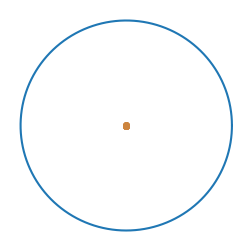

In [6]:
# create Poincare disk
D = PoincareDisk()
D.sample_random(num_points=15, radius=0.001)
D.visualize(size=3, circle=True, numbers=False)

In [7]:
# use them to create embedding object
E = Embedding(G, D)
avg_distortion_initial = E.avg_distortion_vec(E._disk.data_points)
normal_avg_distortion_initial = E.normal_avg_distortion_vec(E._disk.data_points)
print(f"Average distortion after initialization: {avg_distortion_initial}.")
print(f"Normalized average distortion after initialization: {normal_avg_distortion_initial}.")

Average distortion after initialization: 0.9992279410362244.
Normalized average distortion after initialization: 24.720766067504883.


In [8]:
# start optimization
epochs = 1000
distortions = E.RSGD(num_epochs=epochs, autograd=True, distortion="avg")

Average distortion after 1000. epoch: 0.1299663931131363.


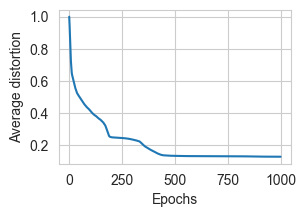

In [9]:
# show distortions during optimization process
plt.figure(figsize=(3, 2))
plt.plot(torch.arange(epochs+1), distortions)
plt.xlabel("Epochs")
plt.ylabel("Average distortion")
plt.show()

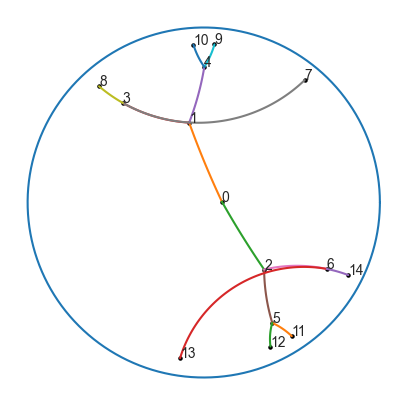

In [10]:
# visualize disk after optimization
E.visualize(size_point=5, size_fig=5, show_circle=True, show_numbers=True, show_geodesics=True)